Phase 1: Data Audit (EDA)

In [2]:
# Step 1: Load Dataset
import pandas as pd

df = pd.read_csv("data/ecommerce_500k.csv")

print(df.shape)
df.head()

(500000, 30)


,order_id,customer_id,product_id,order_date,category,sub_category,product_base_price,discount_percentage,final_price,quantity,...,city,loyalty_tier,is_first_purchase,customer_lifetime_value,session_duration_mins,pages_viewed,clicks_to_purchase,is_returned,return_reason,is_cancelled
0,1000001,25795,90,2022-07-31,Clothing,Men,70.41,25,52.81,1,...,Bangalore,Bronze,0,457.77,4.6,35.0,7,0,NaN,0
1,1000002,10860,1917,2023-09-25,Automotive,Car Care,6.02,10,5.42,3,...,Toronto,Bronze,0,1606.42,2.9,8.0,8,0,NaN,0
2,1000003,86820,805,2022-03-26,Books,Textbooks,78.85,20,63.08,2,...,Chicago,Silver,0,252.16,5.5,38.0,8,0,NaN,0
3,1000004,64886,3379,2022-11-03,Books,Non-Fiction,58.42,25,43.82,4,...,Sydney,Bronze,0,645.12,6.1,30.0,9,0,NaN,0
4,1000005,16265,4604,2022-06-30,Clothing,Women,73.38,15,62.37,1,...,Manchester,Bronze,1,1103.24,1.6,38.0,11,0,NaN,0


In [3]:
# Step 2: Understand Data Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   order_id                 500000 non-null  int64  
 1   customer_id              500000 non-null  int64  
 2   product_id               500000 non-null  int64  
 3   order_date               500000 non-null  object 
 4   category                 500000 non-null  object 
 5   sub_category             500000 non-null  object 
 6   product_base_price       500000 non-null  float64
 7   discount_percentage      500000 non-null  int64  
 8   final_price              500000 non-null  float64
 9   quantity                 500000 non-null  int64  
 10  total_amount             500000 non-null  float64
 11  shipping_cost            484934 non-null  float64
 12  shipping_method          500000 non-null  object 
 13  days_to_deliver          484751 non-null  float64
 14  paym

In [6]:
# Step 3: Missing Value Analysis
df.isnull().sum()

order_id                        0
customer_id                     0
product_id                      0
order_date                      0
category                        0
sub_category                    0
product_base_price              0
discount_percentage             0
final_price                     0
quantity                        0
total_amount                    0
shipping_cost               15066
shipping_method                 0
days_to_deliver             15249
payment_method                  0
rating                      14990
num_reviews                     0
customer_age                14928
customer_gender                 0
country                         0
city                            0
loyalty_tier                    0
is_first_purchase               0
customer_lifetime_value     15004
session_duration_mins       14725
pages_viewed                14814
clicks_to_purchase              0
is_returned                     0
return_reason              440096
is_cancelled  

In [7]:
# Step 4: Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [8]:
# Step 5: Statistical Summary
df.describe()

,order_id,customer_id,product_id,product_base_price,discount_percentage,final_price,quantity,total_amount,shipping_cost,days_to_deliver,rating,num_reviews,customer_age,is_first_purchase,customer_lifetime_value,session_duration_mins,pages_viewed,clicks_to_purchase,is_returned,is_cancelled
count,5.000000e+05,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,484934.000000,484751.000000,485010.000000,500000.000000,485072.000000,500000.000000,484996.000000,485275.000000,485186.000000,500000.000000,500000.000000,500000.000000
mean,1.250000e+06,55007.627196,2503.810058,84.833241,14.599090,72.438608,2.284080,165.605507,34.031570,4.238345,3.796253,27.015930,34.953966,0.278630,850.516871,8.511644,25.054783,9.999486,0.119808,0.061662
std,1.443377e+05,25995.094710,1441.201322,79.984198,12.943309,69.900582,1.739378,237.412198,39.185919,2.398417,0.943732,16.425337,11.132444,0.448325,799.762647,8.035044,14.142187,5.475479,0.324737,0.240541
min,1.000001e+06,10000.000000,1.000000,5.000000,0.000000,2.500000,1.000000,2.500000,0.000000,1.000000,1.000000,0.000000,18.000000,0.000000,50.000000,0.500000,1.000000,1.000000,0.000000,0.000000
25%,1.125001e+06,32490.000000,1259.000000,28.040000,0.000000,23.440000,1.000000,37.710000,4.540000,3.000000,3.500000,15.000000,26.000000,0.000000,280.180000,2.800000,13.000000,5.000000,0.000000,0.000000
50%,1.250000e+06,55056.500000,2503.000000,60.220000,15.000000,50.590000,2.000000,87.700000,24.890000,4.000000,4.000000,24.000000,35.000000,0.000000,604.170000,6.100000,25.000000,10.000000,0.000000,0.000000
75%,1.375000e+06,77510.000000,3752.000000,115.580000,20.000000,98.110000,3.000000,194.070000,44.020000,5.000000,4.500000,36.000000,43.000000,1.000000,1160.032500,11.600000,37.000000,15.000000,0.000000,0.000000
max,1.500000e+06,99998.000000,5000.000000,1148.770000,50.000000,1091.330000,10.000000,6617.300000,200.000000,14.000000,5.000000,166.000000,80.000000,1.000000,11606.040000,121.400000,49.000000,19.000000,1.000000,1.000000


Phase 2: Pricing Data Skewness

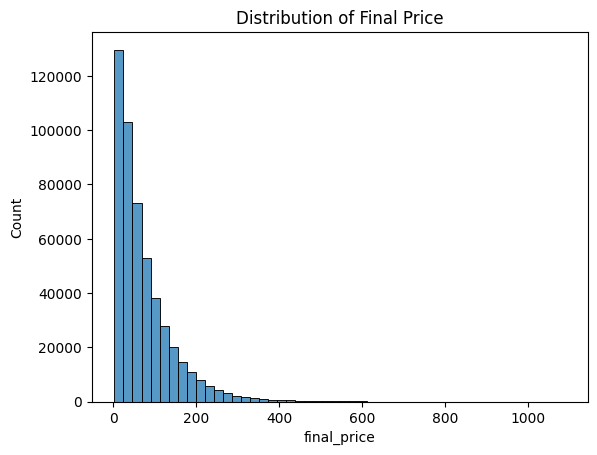

In [10]:
# Histogram
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['final_price'], bins=50)
plt.title("Distribution of Final Price")
plt.show()

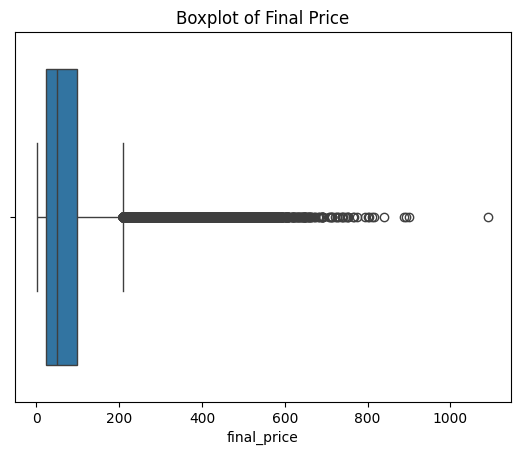

In [11]:
# Boxplot
sns.boxplot(x=df['final_price'])
plt.title("Boxplot of Final Price")
plt.show()

In [13]:
# Calculate Skewness
df['final_price'].skew()

np.float64(2.107808818591687)

Phase 3: Find Categorical Columns

In [14]:
# Find categorical columns
print(df.select_dtypes(include='object').columns)

Index(['order_date', 'category', 'sub_category', 'shipping_method',
       'payment_method', 'customer_gender', 'country', 'city', 'loyalty_tier',
       'return_reason'],
      dtype='object')


In [15]:
# Count unique values
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].nunique())

order_date 1095
category 10
sub_category 45
shipping_method 4
payment_method 6
customer_gender 3
country 8
city 15
loyalty_tier 4
return_reason 5


In [16]:
# Phase 4: Why Are Products Returned?
print(df['is_returned'].value_counts())

is_returned
0    440096
1     59904
Name: count, dtype: int64


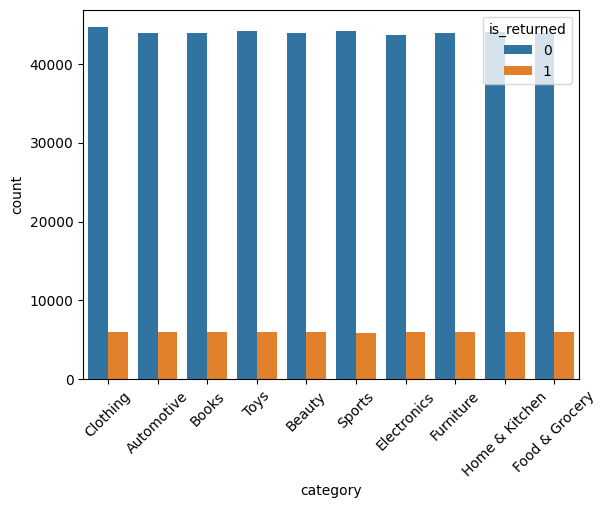

In [19]:
# Category vs Return
sns.countplot(data=df, x='category', hue='is_returned')
plt.xticks(rotation=45)
plt.show()

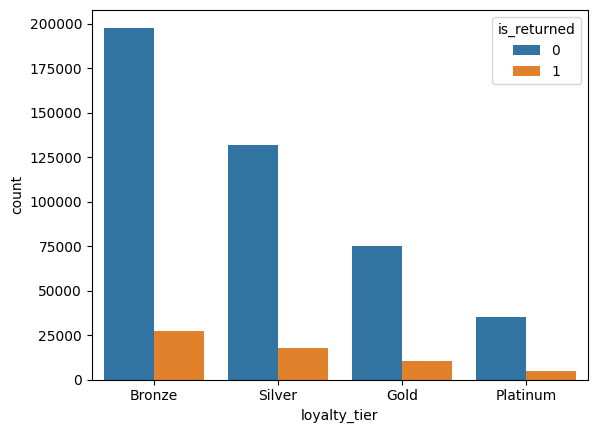

In [20]:
# Loyalty Tier vs Return
sns.countplot(data=df, x='loyalty_tier', hue='is_returned')
plt.show()

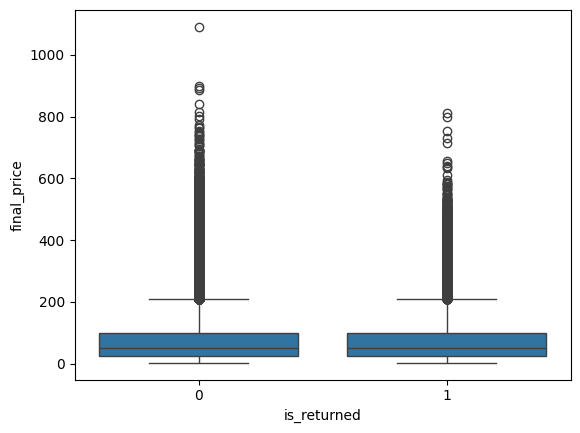

In [21]:
# Price vs Return
sns.boxplot(data=df, x='is_returned', y='final_price')
plt.show()

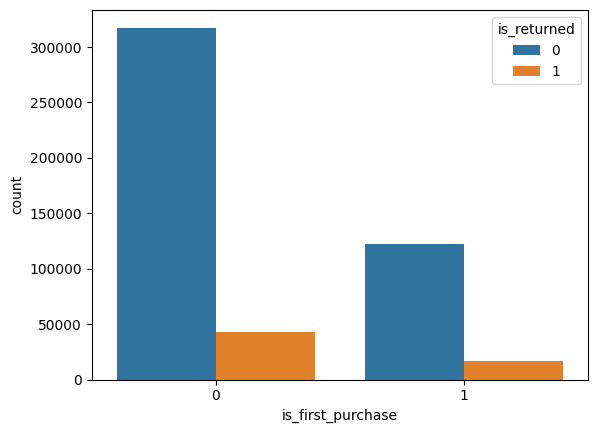

In [22]:
# First Purchase vs Return
sns.countplot(data=df, x='is_first_purchase', hue='is_returned')
plt.show()

Phase 5: Feature Engineering

In [23]:
# Check missing values
print(df.isnull().sum())

order_id                        0
customer_id                     0
product_id                      0
order_date                      0
category                        0
sub_category                    0
product_base_price              0
discount_percentage             0
final_price                     0
quantity                        0
total_amount                    0
shipping_cost               15066
shipping_method                 0
days_to_deliver             15249
payment_method                  0
rating                      14990
num_reviews                     0
customer_age                14928
customer_gender                 0
country                         0
city                            0
loyalty_tier                    0
is_first_purchase               0
customer_lifetime_value     15004
session_duration_mins       14725
pages_viewed                14814
clicks_to_purchase              0
is_returned                     0
return_reason              440096
is_cancelled  

In [28]:
# Fill Numerical Missing Values
df['shipping_cost'] = df['shipping_cost'].fillna(df['shipping_cost'].median())

df['days_to_deliver'] = df['days_to_deliver'].fillna(df['days_to_deliver'].median())

df['rating'] = df['rating'].fillna(df['rating'].median())

df['customer_age'] = df['customer_age'].fillna(df['customer_age'].median())

df['customer_lifetime_value'] = df['customer_lifetime_value'].fillna(df['customer_lifetime_value'].median())

df['session_duration_mins'] = df['session_duration_mins'].fillna(df['session_duration_mins'].median())

df['pages_viewed'] = df['pages_viewed'].fillna(df['pages_viewed'].median())

df['return_reason'] = df['return_reason'].fillna('No Return')

In [29]:
df.isnull().sum()

order_id                   0
customer_id                0
product_id                 0
order_date                 0
category                   0
sub_category               0
product_base_price         0
discount_percentage        0
final_price                0
quantity                   0
total_amount               0
shipping_cost              0
shipping_method            0
days_to_deliver            0
payment_method             0
rating                     0
num_reviews                0
customer_age               0
customer_gender            0
country                    0
city                       0
loyalty_tier               0
is_first_purchase          0
customer_lifetime_value    0
session_duration_mins      0
pages_viewed               0
clicks_to_purchase         0
is_returned                0
return_reason              0
is_cancelled               0
dtype: int64

In [30]:
# Encode Categorical Columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['customer_gender'] = le.fit_transform(df['customer_gender'])
df['payment_method'] = le.fit_transform(df['payment_method'])
df['shipping_method'] = le.fit_transform(df['shipping_method'])
df['category'] = le.fit_transform(df['category'])
df['sub_category'] = le.fit_transform(df['sub_category'])

In [31]:
# Create New Feature
df['price_per_item'] = df['final_price'] / df['quantity']

Phase 6: Correlation and HeatMap

In [37]:
# Correlation Analysis
df.corr(numeric_only=True)

,order_id,customer_id,product_id,category,sub_category,product_base_price,discount_percentage,final_price,quantity,total_amount,...,customer_age,customer_gender,is_first_purchase,customer_lifetime_value,session_duration_mins,pages_viewed,clicks_to_purchase,is_returned,is_cancelled,price_per_item
order_id,1.000000,0.000963,-0.002462,0.000470,-0.001118,0.000106,0.000253,0.000464,-2.329855e-04,-0.000390,...,0.000838,-0.000674,0.000233,-0.000009,0.000719,0.001686,-0.003346,0.002068,-0.001975,0.000708
customer_id,0.000963,1.000000,-0.000662,-0.000663,-0.001387,-0.000887,-0.000880,-0.000832,-5.076655e-04,-0.001924,...,0.001041,-0.000112,-0.001450,-0.001700,-0.000423,0.000250,-0.002652,-0.001203,0.000985,0.000192
product_id,-0.002462,-0.000662,1.000000,0.000853,-0.001883,-0.001356,-0.001079,-0.001279,1.955215e-03,0.001648,...,-0.000153,-0.000233,0.001550,0.002262,-0.001767,0.001767,-0.002768,-0.001383,-0.000842,-0.002624
category,0.000470,-0.000663,0.000853,1.000000,-0.149100,-0.000137,0.000191,-0.000096,-1.922119e-03,-0.002013,...,0.000310,0.000397,0.000135,-0.001129,0.002854,-0.000206,0.002269,-0.001271,0.000984,0.001012
sub_category,-0.001118,-0.001387,-0.001883,-0.149100,1.000000,0.001436,-0.000610,0.001437,7.915467e-04,0.000592,...,0.000685,0.003861,-0.003633,-0.001230,-0.002386,-0.001236,-0.003013,0.000580,0.000288,0.001344
product_base_price,0.000106,-0.000887,-0.001356,-0.000137,0.001436,1.000000,0.000941,0.976290,1.357726e-03,0.659634,...,-0.001878,0.000834,-0.000112,-0.000969,-0.001243,-0.000283,0.001058,-0.001294,0.000382,0.785902
discount_percentage,0.000253,-0.000880,-0.001079,0.000191,-0.000610,0.000941,1.000000,-0.156454,8.968274e-04,-0.104974,...,0.002523,-0.001202,0.001693,-0.001457,0.000826,0.001856,-0.001003,0.002670,-0.000228,-0.126686
final_price,0.000464,-0.000832,-0.001279,-0.000096,0.001437,0.976290,-0.156454,1.000000,1.233156e-03,0.675412,...,-0.002065,0.001326,-0.000619,-0.000890,-0.000865,-0.000267,0.001084,-0.001599,0.000235,0.805115
quantity,-0.000233,-0.000508,0.001955,-0.001922,0.000792,0.001358,0.000897,0.001233,1.000000e+00,0.531041,...,-0.000211,0.004480,-0.001843,0.000752,-0.000146,-0.000018,0.000192,-0.000420,0.000590,-0.358527
total_amount,-0.000390,-0.001924,0.001648,-0.002013,0.000592,0.659634,-0.104974,0.675412,5.310413e-01,1.000000,...,-0.000203,0.003026,-0.000950,-0.001275,-0.001341,-0.000213,0.000415,-0.001512,0.000699,0.174619


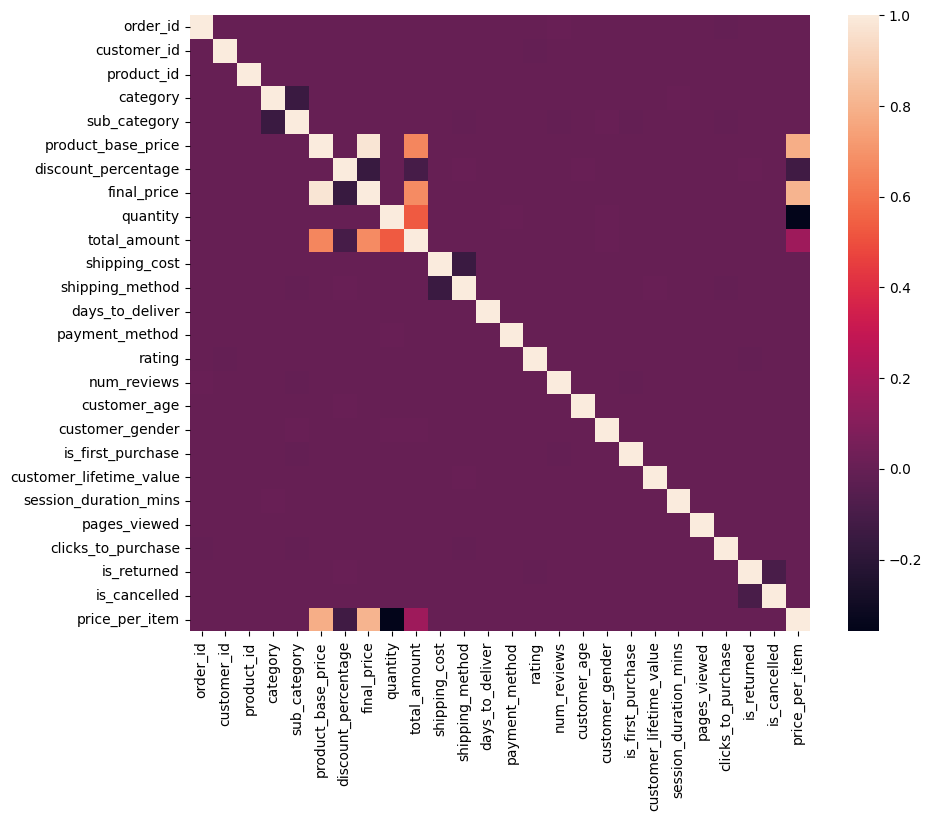

In [38]:
# Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True))
plt.show()